In [1]:
import torch

device = torch.device("xpu" if torch.xpu.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", device)

if torch.xpu.is_available():
    print("GPU:", torch.xpu.get_device_name(0))

PyTorch: 2.13.0+xpu
Device: xpu
GPU: Intel(R) Arc(TM) Graphics


In [2]:
%pip install pandas
%pip install imagehash
%pip install gTTS
%pip install playsound
%pip install pyttsx3
%pip install tensorflow
%pip install opencv-python
%pip install pillow
%pip install seaborn
%pip install scikit-learn
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Using cached playsound-1.3.0.tar.gz (7.7 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'
Note: you may need to restart the kernel to use updated packages.


  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [29 lines of output]
  Traceback (most recent call last):
    File "C:\Users\Manoj Srivathsava\intel-gpu\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
      main()
    File "C:\Users\Manoj Srivathsava\intel-gpu\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
      json_out["return_val"] = hook(**hook_input["kwargs"])
                               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    File "C:\Users\Manoj Srivathsava\intel-gpu\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 143, in get_requires_for_build_wheel
      return hook(config_settings)
             ^^^^^^^^^^^^^^^^^^^^^
    File "C:\Users\Manoj Srivathsava\AppData\Local\Temp\pip-build-env-76ho5ztp\overlay\Lib\site-packages\setuptools\build_meta.py", line 333, in get_requires_for_buil

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import zipfile
import cv2
from PIL import Image
import imagehash
import tensorflow as tf
import seaborn as sns
from collections import Counter
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')


In [4]:
asl_zip_path = "ASL_SemCom.zip"
isl_zip_path = "ISL.zip"
asl_extract_path = "ASL_dataset"
isl_extract_path = "ISL_dataset"

In [5]:
os.makedirs(asl_extract_path, exist_ok=True)
os.makedirs(isl_extract_path, exist_ok=True)

# Unzipping ASL Dataset
print("Unzipping ASL dataset...")
with zipfile.ZipFile(asl_zip_path, 'r') as zip_ref:
    zip_ref.extractall(asl_extract_path)
print(" ASL dataset extracted to:", asl_extract_path)

# Unzipping ISL Dataset
print("Unzipping ISL dataset...")
with zipfile.ZipFile(isl_zip_path, 'r') as zip_ref:
    zip_ref.extractall(isl_extract_path)
print(" ISL dataset extracted to:", isl_extract_path)

Unzipping ASL dataset...
 ASL dataset extracted to: ASL_dataset
Unzipping ISL dataset...
 ISL dataset extracted to: ISL_dataset


In [6]:
def show_sample_images(dataset_path, title="Sample Images", max_classes=10, img_size=(64,64)):
    print(f"Loading samples from: {dataset_path}")

    class_folders = sorted([f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))])
    print(f" Found {len(class_folders)} classes")

    plt.figure(figsize=(18, 8))
    plt.suptitle(title, fontsize=16)

    displayed = 0
    for i, class_name in enumerate(class_folders[:max_classes]):
        class_dir = os.path.join(dataset_path, class_name)
        image_files = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        print(f" Class '{class_name}': {len(image_files)} images found")

        if len(image_files) == 0:
            continue

        img_path = os.path.join(class_dir, image_files[0])
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)

        if img is None:
            print(f" Failed to read image: {img_path}")
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size)

        plt.subplot(4, 5, displayed + 1)
        plt.imshow(img)
        plt.title(f"{class_name}")
        plt.axis('off')

        displayed += 1

    if displayed == 0:
        print(" No valid images could be loaded.")
    else:
        plt.tight_layout()
        plt.show()

Loading samples from: ASL_dataset/Train
 Found 24 classes
 Class 'A': 447 images found
 Class 'B': 443 images found
 Class 'C': 437 images found
 Class 'D': 439 images found
 Class 'E': 441 images found
 Class 'F': 443 images found
 Class 'G': 435 images found
 Class 'H': 432 images found
 Class 'I': 433 images found
 Class 'K': 455 images found


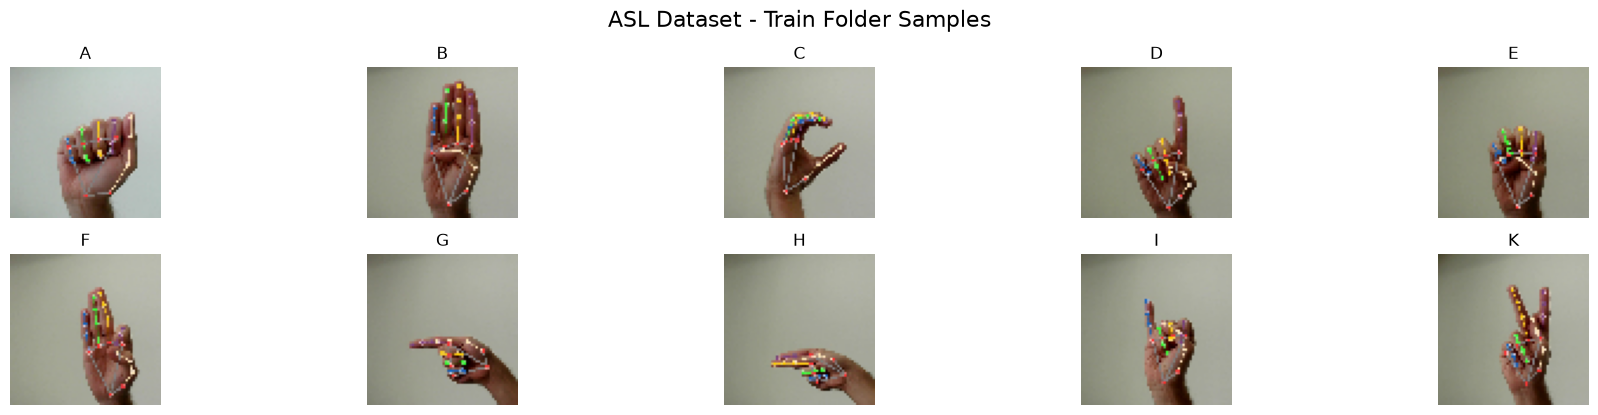

In [7]:
show_sample_images('ASL_dataset/Train', title="ASL Dataset - Train Folder Samples")


Loading samples from: ISL_dataset/data
 Found 35 classes
 Class '1': 1200 images found
 Class '2': 1200 images found
 Class '3': 1200 images found
 Class '4': 1200 images found
 Class '5': 1200 images found
 Class '6': 1200 images found
 Class '7': 1200 images found
 Class '8': 1200 images found
 Class '9': 1200 images found
 Class 'A': 1200 images found


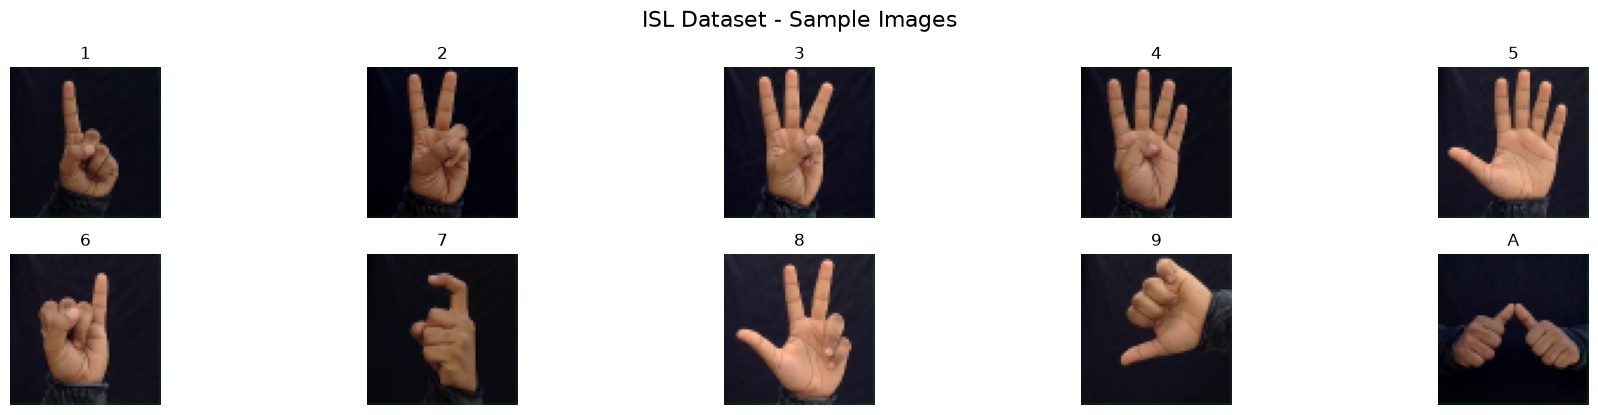

In [8]:
show_sample_images('ISL_dataset/data', title="ISL Dataset - Sample Images")

In [9]:
# counting images per class in a dataset folder
def count_classes(data_dir):
    class_counts = {}
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):

            img_count = len([f for f in os.listdir(class_path) if f.lower().endswith(('png', 'jpg', 'jpeg'))])
            class_counts[class_name] = img_count
    return class_counts

asl_data_dir = "ASL_dataset/Train"
isl_data_dir = "ISL_dataset/data"

asl_class_counts = count_classes(asl_data_dir)
isl_class_counts = count_classes(isl_data_dir)

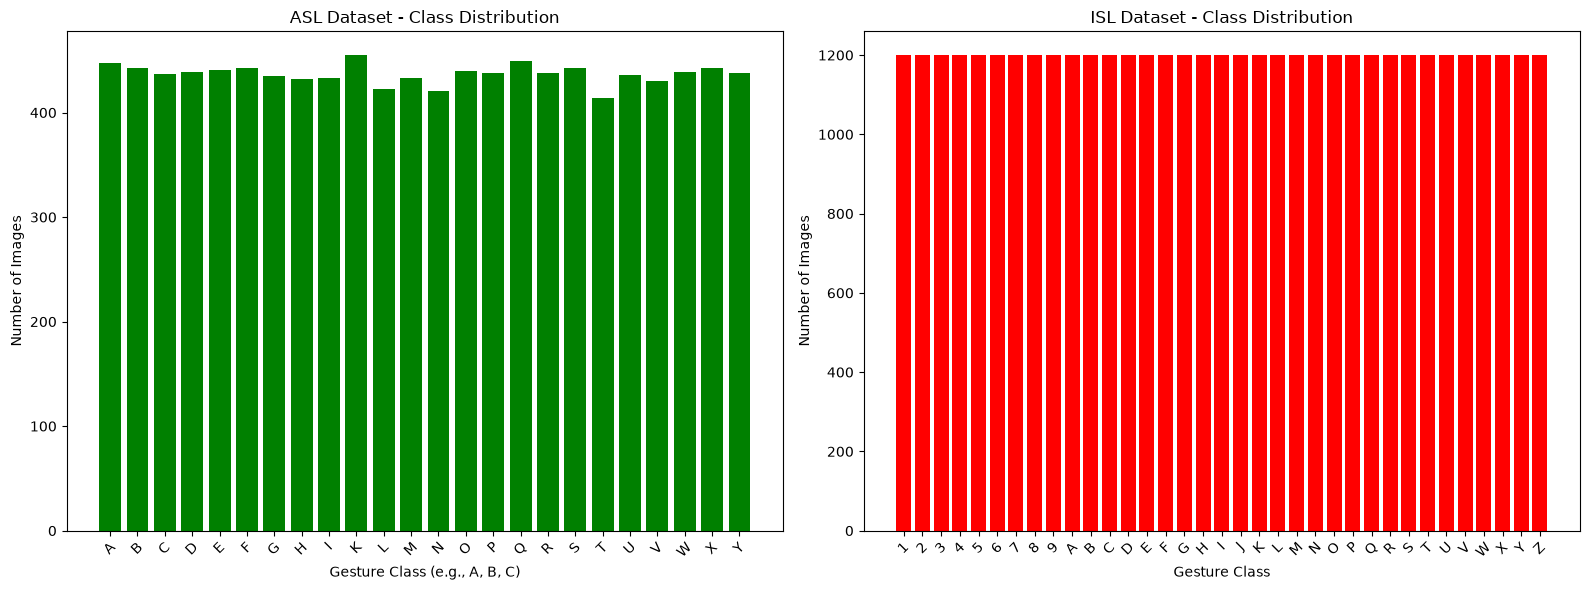

In [10]:
# Plotting Class Distribution
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# ASL
ax[0].bar(asl_class_counts.keys(), asl_class_counts.values(), color='green')
ax[0].set_title("ASL Dataset - Class Distribution")
ax[0].set_xlabel("Gesture Class (e.g., A, B, C)")
ax[0].set_ylabel("Number of Images")
ax[0].tick_params(axis='x', rotation=45)

# ISL
ax[1].bar(isl_class_counts.keys(), isl_class_counts.values(), color='red')
ax[1].set_title("ISL Dataset - Class Distribution")
ax[1].set_xlabel("Gesture Class")
ax[1].set_ylabel("Number of Images")
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [11]:
def count_total_images(dataset_path):

    image_count = 0
    supported_formats = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(supported_formats):
                image_count += 1
    return image_count

asl_dataset_path = "ASL_dataset"
isl_dataset_path = "ISL_dataset"

# Counting images
num_asl_images = count_total_images(asl_dataset_path)
num_isl_images = count_total_images(isl_dataset_path)

print(f"Total number of images in ASL dataset: {num_asl_images}")
print(f"Total number of images in ISL dataset: {num_isl_images}")


Total number of images in ASL dataset: 12290
Total number of images in ISL dataset: 42000


In [12]:
ISL_DATASET_PATH = "ISL_dataset/data"
max_images = 100
allowed_extensions = ('.png', '.jpg', '.jpeg')

for class_name in sorted(os.listdir(ISL_DATASET_PATH)):
    class_path = os.path.join(ISL_DATASET_PATH, class_name)
    if not os.path.isdir(class_path):
        continue

    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(allowed_extensions)]
    unique_images = {}
    hash_set = set()

    for img_file in sorted(image_files):
        img_path = os.path.join(class_path, img_file)

        try:
            with Image.open(img_path) as img:
                img_hash = imagehash.phash(img)
        except Exception as e:
            print(f" Error reading {img_path}: {e}")
            continue


        if img_hash in hash_set:
            os.remove(img_path)
        else:
            hash_set.add(img_hash)
            unique_images[img_file] = img_hash

        if len(hash_set) >= max_images:
            break

    kept_files = set(unique_images.keys())
    for img_file in image_files:
        if img_file not in kept_files:
            try:
                os.remove(os.path.join(class_path, img_file))
            except:
                pass

    print(f"'{class_name}': {len(kept_files)}  images" )


'1': 100  images
'2': 100  images
'3': 100  images
'4': 100  images
'5': 80  images
'6': 100  images
'7': 100  images
'8': 100  images
'9': 100  images
'A': 100  images
'B': 100  images
'C': 100  images
'D': 100  images
'E': 100  images
'F': 90  images
'G': 100  images
'H': 100  images
'I': 100  images
'J': 100  images
'K': 100  images
'L': 100  images
'M': 81  images
'N': 100  images
'O': 100  images
'P': 100  images
'Q': 100  images
'R': 100  images
'S': 100  images
'T': 100  images
'U': 100  images
'V': 100  images
'W': 100  images
'X': 100  images
'Y': 100  images
'Z': 100  images


In [13]:
DATASET_DIR = ISL_DATASET_PATH
IMG_SIZE =64
BATCH_SIZE = 32
SEED = 42

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False
)

train_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

val_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)


base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False


x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(train_gen.num_classes, activation='softmax')(x)
isl_model = Model(inputs=base_model.input, outputs=predictions)

isl_model.summary()

Found 2761 images belonging to 35 classes.
Found 690 images belonging to 35 classes.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 32, 32,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 32, 32,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 32, 32,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 32, 32,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 32, 32,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 32, 32,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 32, 32,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 32, 32,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 33, 33,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 16, 16,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 16, 16,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 16, 16,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 16, 16,    │      2,304 │ block_1_depthwis

 Total params: 2,426,467 (9.26 MB)

 Trainable params: 168,483 (658.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
isl_model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


history = isl_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5
)



Epoch 1/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 17s 129ms/step - accuracy: 0.5411 - loss: 1.8697 - val_accuracy: 0.9478 - val_loss: 0.3977
Epoch 2/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.8982 - loss: 0.4382 - val_accuracy: 0.9783 - val_loss: 0.1437
Epoch 3/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.9366 - loss: 0.2445 - val_accuracy: 0.9812 - val_loss: 0.1112
Epoch 4/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - accuracy: 0.9504 - loss: 0.1811 - val_accuracy: 0.9812 - val_loss: 0.0783
Epoch 5/5
87/87 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.9681 - loss: 0.1423 - val_accuracy: 0.9884 - val_loss: 0.0632


In [15]:
val_loss, val_acc = isl_model.evaluate(val_gen)
print(f" Validation Accuracy for isl : {val_acc * 100:.2f}%")
print(f" Validation Loss for isl : {val_loss:.2f}")

22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.9826 - loss: 0.0665 
 Validation Accuracy for isl : 98.26%
 Validation Loss for isl : 0.07


In [16]:
img_size = (128, 128)
batch_size = 32
input_shape = (128, 128, 1)

asl_dataset_path = 'ASL_dataset'

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

asl_train_gen = datagen.flow_from_directory(
    asl_dataset_path,
    target_size=img_size,
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

asl_val_gen = datagen.flow_from_directory(
    asl_dataset_path,
    target_size=img_size,
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_asl_classes = len(asl_train_gen.class_indices)
print(f"\n Number of ASL Classes: {num_asl_classes}")
print(f" Class Labels: {asl_train_gen.class_indices}")

Found 9832 images belonging to 2 classes.
Found 2458 images belonging to 2 classes.

 Number of ASL Classes: 2
 Class Labels: {'Test': 0, 'Train': 1}


In [17]:
def create_cnn_model(input_shape, num_classes):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2,2)),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D((2,2)),

        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D((2,2)),

        Conv2D(128, (3,3), activation='relu'),
        MaxPooling2D((2,2)),

        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

asl_model = create_cnn_model(input_shape, num_asl_classes)
asl_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,601,090 (9.92 MB)

 Trainable params: 2,601,090 (9.92 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history_asl = asl_model.fit(
    asl_train_gen,
    validation_data=asl_val_gen,
    epochs=10
)

Epoch 1/10
308/308 ━━━━━━━━━━━━━━━━━━━━ 222s 713ms/step - accuracy: 0.8525 - loss: 0.3727 - val_accuracy: 0.8600 - val_loss: 0.3922
Epoch 2/10
308/308 ━━━━━━━━━━━━━━━━━━━━ 69s 222ms/step - accuracy: 0.8739 - loss: 0.2868 - val_accuracy: 0.8552 - val_loss: 0.4026
Epoch 3/10
308/308 ━━━━━━━━━━━━━━━━━━━━ 71s 232ms/step - accuracy: 0.9173 - loss: 0.2072 - val_accuracy: 0.8788 - val_loss: 0.3975
Epoch 4/10
308/308 ━━━━━━━━━━━━━━━━━━━━ 75s 242ms/step - accuracy: 0.9585 - loss: 0.1104 - val_accuracy: 0.8942 - val_loss: 0.4517
Epoch 5/10
308/308 ━━━━━━━━━━━━━━━━━━━━ 77s 250ms/step - accuracy: 0.9729 - loss: 0.0703 - val_accuracy: 0.8849 - val_loss: 0.5747
Epoch 6/10
308/308 ━━━━━━━━━━━━━━━━━━━━ 72s 234ms/step - accuracy: 0.9832 - loss: 0.0494 - val_accuracy: 0.9068 - val_loss: 0.4769
Epoch 7/10
308/308 ━━━━━━━━━━━━━━━━━━━━ 70s 226ms/step - accuracy: 0.9905 - loss: 0.0302 - val_accuracy: 0.9125 - val_loss: 0.4210
Epoch 8/10
308/308 ━━━━━━━━━━━━━━━━━━━━ 75s 244ms/step - accuracy: 0.9902 - loss: 

In [19]:
# Evaluating ASL model
asl_loss, asl_acc = asl_model.evaluate(asl_val_gen)
print(f"Final ASL Model Validation Accuracy: {asl_acc * 100:.2f}%")
print(f" Final ASL Model Validation Loss: {asl_loss:.2f}")

77/77 ━━━━━━━━━━━━━━━━━━━━ 11s 138ms/step - accuracy: 0.9072 - loss: 0.5194
Final ASL Model Validation Accuracy: 90.72%
 Final ASL Model Validation Loss: 0.52


In [20]:
print(" Evaluating ISL Model (MobileNetV2) on Test Data...")

isl_test_loss, isl_test_acc = isl_model.evaluate(val_gen, verbose=0)
print(f"   ISL Model - Test Loss: {isl_test_loss:.4f}")

print(" Evaluating ASL Model (CNN) on Test Data...")

asl_test_loss, asl_test_acc = asl_model.evaluate(asl_val_gen, verbose=0)


print("\n" + "="*50)
print(" FINAL TEST ACCURACY COMPARISON")
print("="*50)
print(f"ASL Model (CNN)        : {asl_test_acc * 100:.2f}%")
print(f"ISL Model (MobileNetV2): {isl_test_acc * 100:.2f}%")

 Evaluating ISL Model (MobileNetV2) on Test Data...
   ISL Model - Test Loss: 0.0659
 Evaluating ASL Model (CNN) on Test Data...

 FINAL TEST ACCURACY COMPARISON
ASL Model (CNN)        : 90.07%
ISL Model (MobileNetV2): 98.99%


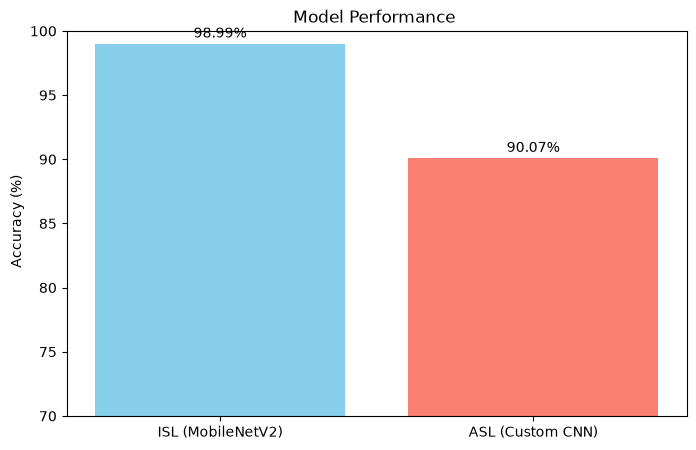

In [21]:
models = ['ISL (MobileNetV2)', 'ASL (Custom CNN)']
accs = [isl_test_acc * 100, asl_test_acc * 100]

plt.figure(figsize=(8, 5))
plt.bar(models, accs, color=['skyblue', 'salmon'])
plt.title('Model Performance ')
plt.ylabel(' Accuracy (%)')
plt.ylim(70, 100)
for i, v in enumerate(accs):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center', fontsize=10)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step

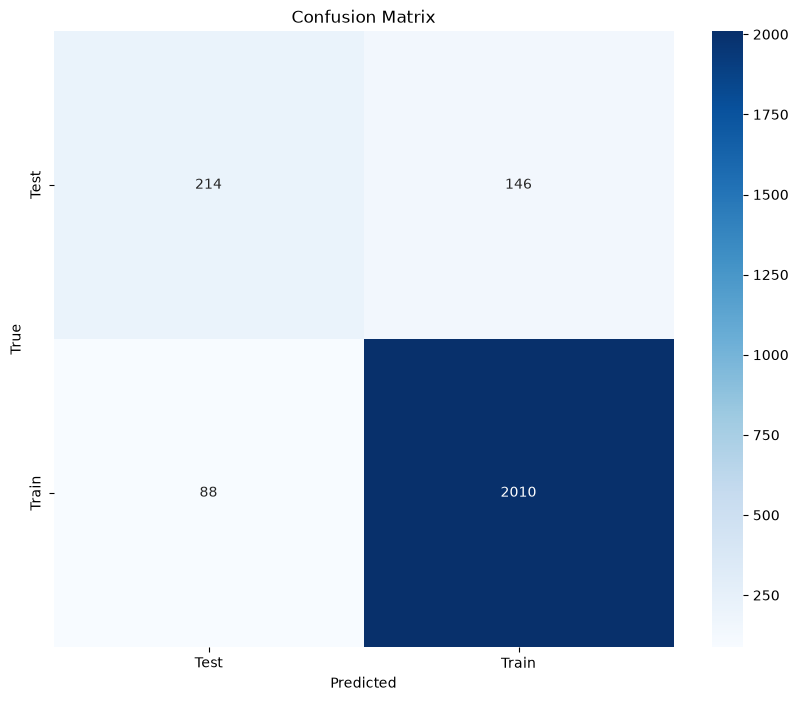

In [22]:
y_true = []
y_pred = []

asl_val_gen.reset()
for i in range(len(asl_val_gen)):
    x, y = asl_val_gen[i]
    pred = asl_model.predict(x)
    y_true.extend(np.argmax(y, axis=1))
    y_pred.extend(np.argmax(pred, axis=1))
    if (i+1) * batch_size >= asl_val_gen.samples:
        break

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=list(asl_val_gen.class_indices.keys())))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=asl_val_gen.class_indices.keys(), yticklabels=asl_val_gen.class_indices.keys(), cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step


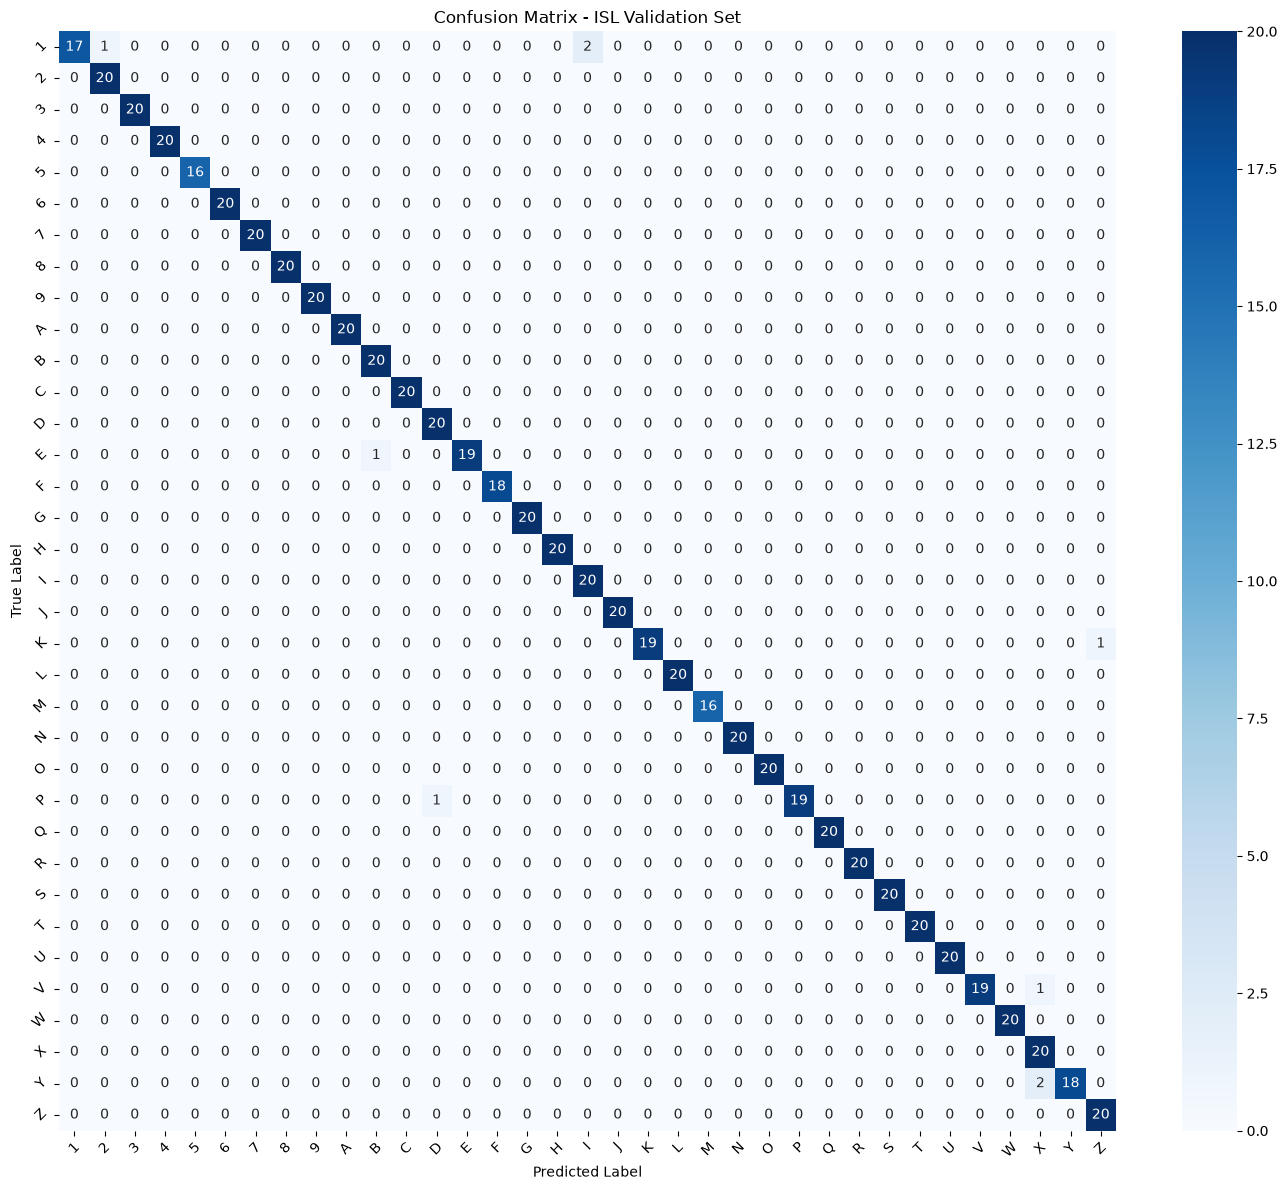

 Classification Report:
              precision    recall  f1-score   support

           1       1.00      0.85      0.92        20
           2       0.95      1.00      0.98        20
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        16
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00        20
           8       1.00      1.00      1.00        20
           9       1.00      1.00      1.00        20
           A       1.00      1.00      1.00        20
           B       0.95      1.00      0.98        20
           C       1.00      1.00      1.00        20
           D       0.95      1.00      0.98        20
           E       1.00      0.95      0.97        20
           F       1.00      1.00      1.00        18
           G       1.00      1.00      1.00        20
           H       1.00      1.00      1.00        20
   

In [23]:
val_gen.reset()
y_pred_probs = isl_model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

y_true = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ISL Validation Set")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

print(" Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))


In [24]:
def plot_training_history(history, title_prefix="Model"):
    acc = history.history.get('accuracy', [])
    val_acc = history.history.get('val_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Accuracy')
    if val_acc:
        plt.plot(epochs, val_acc, 'r*-', label='Validation Accuracy')
    plt.title(f'{title_prefix} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training Loss')
    if val_loss:
        plt.plot(epochs, val_loss, 'r*-', label='Validation Loss')
    plt.title(f'{title_prefix} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(f"{title_prefix.lower()}_training_curves.png")
    plt.show()

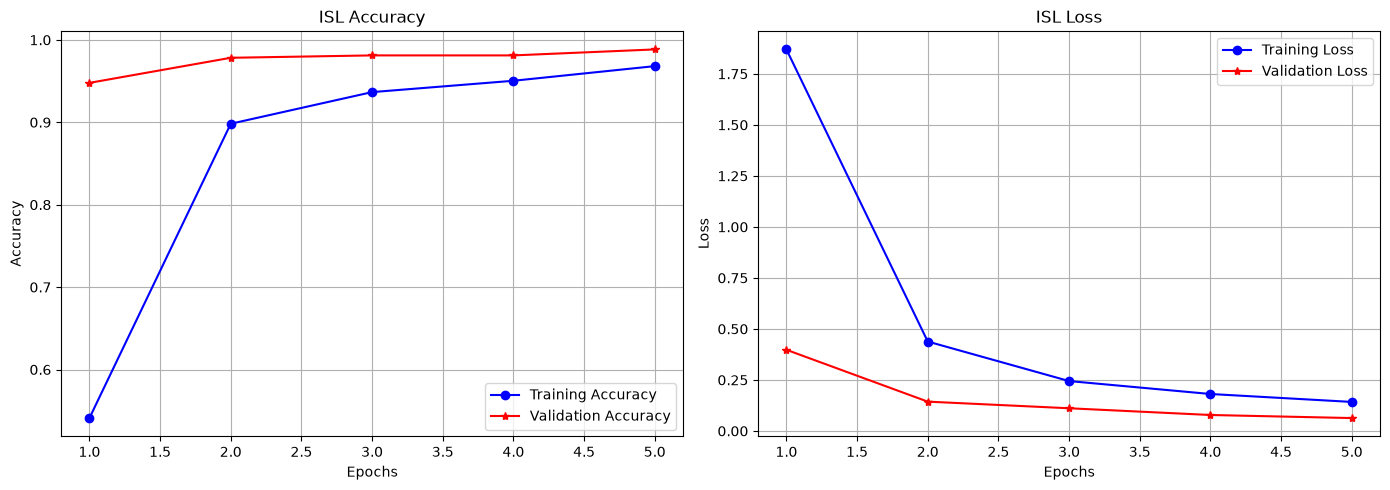

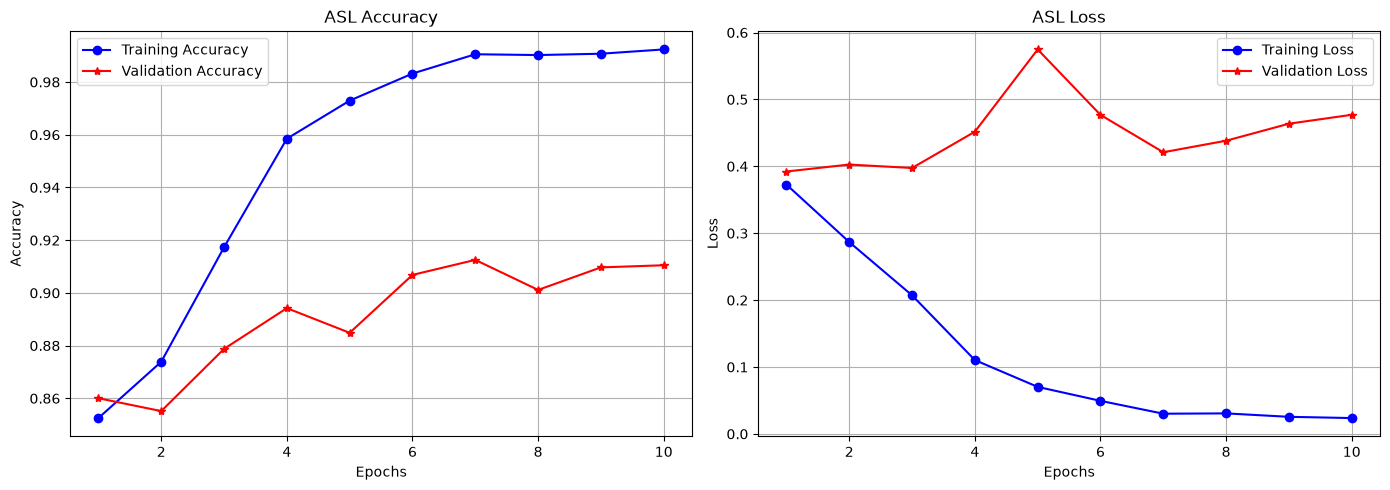

In [25]:
plot_training_history(history, title_prefix="ISL")
plot_training_history(history_asl, title_prefix="ASL")

In [26]:
isl_model.save("isl_model.h5")
asl_model.save("asl_model.h5")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


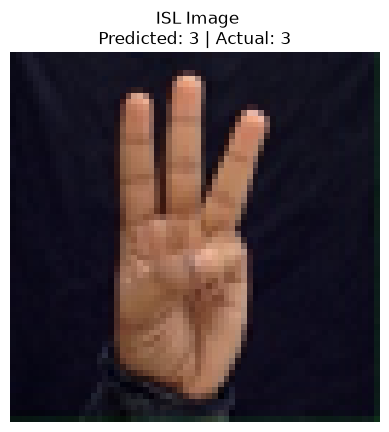

Predicted Class: 3
 Actual Class: 3


In [44]:
from gtts import gTTS
from IPython.display import Audio, display
import random
isl_model = tf.keras.models.load_model("isl_model.h5")

isl_dataset_path = "ISL_dataset/data"
isl_labels = sorted(os.listdir(isl_dataset_path))


def preprocess_image(img_path, input_shape=(64, 64)):
    img = Image.open(img_path).convert("RGB")
    img = img.resize(input_shape)
    img_array = np.array(img).astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array, img

def speak_with_gtts(text, lang='en'):
    try:
        filename = f"temp_{lang}.mp3"
        tts = gTTS(text=text, lang=lang)
        tts.save(filename)
        display(Audio(filename, autoplay=True))
    except Exception as e:
        print(f" TTS Error: {e}")

# Picking a Random ISL Image
def get_random_isl_image(dataset_path):
    class_folder = random.choice(os.listdir(dataset_path))
    class_path = os.path.join(dataset_path, class_folder)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    image_file = random.choice(images)
    image_path = os.path.join(class_path, image_file)
    return image_path, class_folder

# Predict Random Image
def predict_random_isl():
    img_path, actual_class = get_random_isl_image(isl_dataset_path)
    img_array, original_img = preprocess_image(img_path)

    prediction = isl_model.predict(img_array)
    predicted_class = isl_labels[np.argmax(prediction)]

    #  Displaying Image
    plt.imshow(original_img)
    plt.axis('off')
    plt.title(f" ISL Image\nPredicted: {predicted_class} | Actual: {actual_class}", fontsize=12)
    plt.show()

    #  Speaking Prediction
    print(f"Predicted Class: {predicted_class}")
    print(f" Actual Class: {actual_class}")
    speak_with_gtts(f"The predicted sign is {predicted_class}", lang='en')
    speak_with_gtts(f"గుర్తింపు సంకేతం {predicted_class}", lang='te')

predict_random_isl()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step


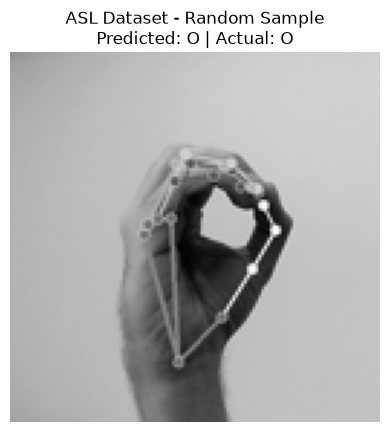

 Predicted Class: O


In [39]:
asl_model = tf.keras.models.load_model("asl_model.h5")

asl_dataset_path = "ASL_dataset/Train"
asl_labels = sorted(os.listdir(asl_dataset_path))

def preprocess_asl_image(img_path, input_shape=(128, 128)):
    img = Image.open(img_path).convert("L")
    img = img.resize(input_shape)
    img_array = np.array(img).astype("float32") / 255.0
    img_array = img_array.reshape(input_shape[0], input_shape[1], 1)
    img_array = np.expand_dims(img_array, axis=0)
    return img_array, img


def speak_with_gtts(text, lang='en'):
    try:
        filename = f"temp_{lang}.mp3"
        tts = gTTS(text=text, lang=lang)
        tts.save(filename)
        display(Audio(filename, autoplay=True))
    except Exception as e:
        print(f"TTS Error: {e}")

def get_random_asl_image(dataset_path):
    class_folder = random.choice(os.listdir(dataset_path))
    class_path = os.path.join(dataset_path, class_folder)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    image_file = random.choice(images)
    image_path = os.path.join(class_path, image_file)
    return image_path, class_folder

# Predicting Random ASL Image
def predict_random_asl():
    img_path, actual_class = get_random_asl_image(asl_dataset_path)
    img_array, original_img = preprocess_asl_image(img_path)

    prediction = asl_model.predict(img_array)
    predicted_class = asl_labels[np.argmax(prediction)]

#  Displaying Image
    plt.imshow(original_img, cmap='gray')
    plt.axis('off')
    plt.title(f"ASL Dataset - Random Sample\nPredicted: {actual_class} | Actual: {actual_class}", fontsize=12)
    plt.show()

#  Speaking Prediction
    print(f" Predicted Class: {actual_class}")

    speak_with_gtts(f"The predicted sign is {actual_class}", lang='en')
    speak_with_gtts(f"ఏఎస్‌ఎల్ గుర్తింపు {actual_class}", lang='te')


predict_random_asl()

In [33]:
%pip install ipywidgets
from PIL import Image
from IPython.display import Javascript, clear_output
import ipywidgets as widgets
import time, base64, os
#from google.colab import output

asl_model = tf.keras.models.load_model("asl_model.h5")
isl_model = tf.keras.models.load_model("isl_model.h5")

asl_labels = sorted(os.listdir("ASL_dataset/Train"))
isl_labels = sorted(os.listdir("ISL_dataset/data"))

def capture_image():

    cap = cv2.VideoCapture(0, cv2.CAP_DSHOW)

    if not cap.isOpened():
        print("Could not open camera.")
        return None

    print("📷 Camera opened.")

    cv2.namedWindow(
        "Capture",
        cv2.WINDOW_NORMAL
    )

    start_time = time.time()

    while time.time() - start_time < 10:

        ret, frame = cap.read()

        if not ret:
            print(" Could not read camera.")
            cap.release()
            cv2.destroyAllWindows()
            return None

        remaining = 10 - int(time.time() - start_time)

        cv2.putText(
            frame,
            f"Capturing in {remaining}...",
            (30, 50),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 0),
            2
        )

        cv2.imshow("Capture", frame)

        cv2.waitKey(30)

    # Capture final frame
    ret, frame = cap.read()

    img_path = "captured_image.jpg"

    if ret:
        cv2.imwrite(img_path, frame)
        print("Image saved:", img_path)
    else:
        print(" Failed to capture final frame.")
        img_path = None

    cap.release()
    cv2.destroyAllWindows()

    return img_path
def preprocess_image(img_path, target_size, mode='rgb'):
    img = Image.open(img_path)
    w, h = img.size
    crop = min(w, h)
    left = (w - crop) // 2
    top = (h - crop) // 2
    img = img.crop((left, top, left + crop, top + crop))
    img = img.resize(target_size)

    if mode == 'grayscale':
        img = img.convert("L")
        arr = np.array(img) / 255.0
        arr = np.expand_dims(np.expand_dims(arr, -1), 0)
    else:
        img = img.convert("RGB")
        arr = np.array(img) / 255.0
        arr = np.expand_dims(arr, 0)

    return arr, img

def predict_image(img_path, lang):
    if lang == 'ISL':
        arr, img = preprocess_image(img_path, (64, 64), mode='rgb')
        preds = isl_model.predict(arr)[0]
        labels = isl_labels
    else:
        arr, img = preprocess_image(img_path, (128, 128), mode='grayscale')
        preds = asl_model.predict(arr)[0]
        labels = asl_labels

    top3 = np.argsort(preds)[-3:][::-1]
    print(f" ({lang}):")
    for i in top3:
        print(f"➡ {labels[i]}: {preds[i]:.4f}")

    return labels[top3[0]], img

def speak_text(text, lang='en'):
    try:
        tts = gTTS(text=text, lang=lang)
        file = f"speak_{lang}.mp3"
        tts.save(file)
        display(Audio(file, autoplay=True))
        time.sleep(1.2)
    except:
        print("TTS Error")

dropdown = widgets.Dropdown(options=['ASL', 'ISL'], value='ASL', description='Sign Type:')
button = widgets.Button(description="Capture & Predict")



Note: you may need to restart the kernel to use updated packages.


In [38]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import os
from PIL import Image
import matplotlib.pyplot as plt

# Create a FRESH UI
dropdown = widgets.Dropdown(
    options=['ASL', 'ISL'],
    value='ASL',
    description='Sign Type:'
)

button = widgets.Button(
    description='Capture & Predict'
)

output_box = widgets.Output()


# Prediction callback
def run_prediction(_):

    with output_box:

        clear_output(wait=True)

        selected = dropdown.value

        print(f"Preparing to capture for {selected}...")
        print("Camera will capture automatically.")

        # Capture image
        img_path = capture_image()

        print("Capture function returned.")
        print("Image path:", img_path)

        if img_path is None:
            print("No image was captured.")
            return

        if not os.path.exists(img_path):
            print("Image file was not found.")
            return

        print("Image captured successfully!")

        # Show captured image
        captured_img = Image.open(img_path)

        display(captured_img)

        # Prediction
        print("\nRunning prediction...")

        label, img = predict_image(
            img_path,
            selected
        )

        print(f"\n Predicted Sign: {label}")

        # Show processed image
        plt.figure(figsize=(5, 5))

        plt.imshow(
            img,
            cmap='gray' if selected == 'ASL' else None
        )

        plt.axis('off')

        plt.title(
            f"{selected} Prediction: {label}"
        )

        plt.show()

        # English speech
        speak_text(
            f"{selected} prediction is {label}",
            lang='en'
        )

        # Telugu speech
        telugu_text = (
            "ఇఎస్‌ఎల్ గుర్తింపు "
            if selected == 'ISL'
            else "ఏఎస్‌ఎల్ గుర్తింపు "
        )

        speak_text(
            telugu_text + label,
            lang='te'
        )


# Attach callback ONCE
button.on_click(run_prediction)


# Display the SAME UI
display(dropdown)
display(button)
display(output_box)

Dropdown(description='Sign Type:', options=('ASL', 'ISL'), value='ASL')

Button(description='Capture & Predict', style=ButtonStyle())

Output()